In [38]:
import pandas as pd
import numpy as np

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, KFold

from scipy.stats import ks_2samp

from xgboost import XGBClassifier

import shap

import matplotlib.pyplot as plt 

In [39]:
df =  pd.read_csv("datasets/kingametric_credit_risk.csv")

In [40]:
df.shape

(8744, 45)

In [41]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

In [42]:
cat_cols = ["Payment_of_Min_Amount", "Credit_Mix", "Payment_Behaviour", "Borrower_Tier"]

df[cat_cols] = df[cat_cols].astype("category")

In [43]:
X = df.drop(columns=["Default_Flag", "Borrower_Tier"], axis=1)
y = df["Default_Flag"]

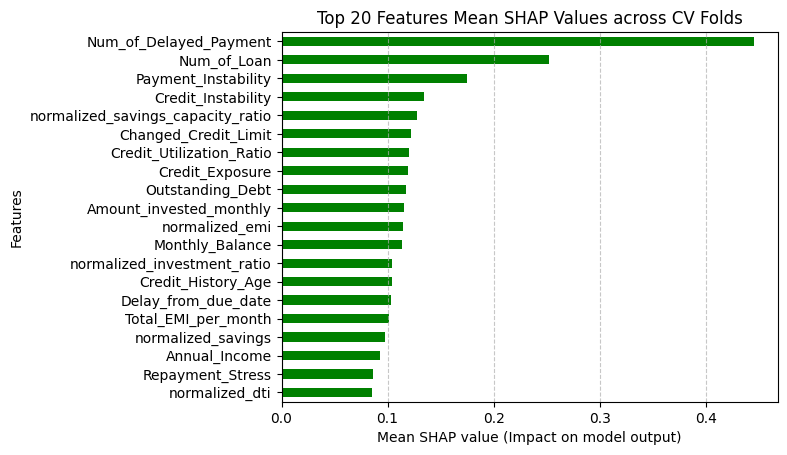

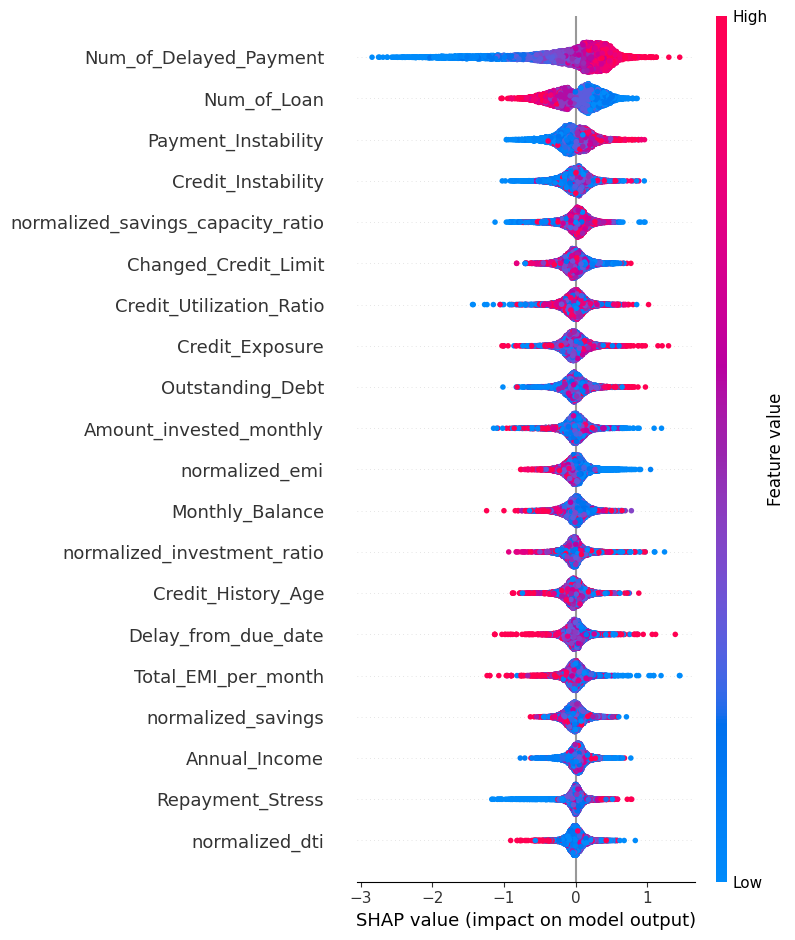

In [44]:
folds = KFold(n_splits=7, shuffle=True, random_state=42)
shap_values_list = []

for train_idx, val_idx in folds.split(X):

    xgb_m = XGBClassifier(enable_categorical=True, tree_method="hist").fit(X.iloc[train_idx], y.iloc[train_idx])

    explainer = shap.TreeExplainer(xgb_m)
    shap_fold = explainer.shap_values(X.iloc[val_idx])
    shap_values_list.append(shap_fold)

all_shap = np.vstack(shap_values_list)
mean_shap = np.abs(all_shap).mean(axis=0)

feature_importance = pd.Series(mean_shap, index=X.columns).sort_values(ascending=False)

#print("Top Features - Mean Absolute SHAP values:")
#print(feature_importance)

plt.Figure(figsize=(10, 6))
feature_importance.head(20).plot(kind="barh", color="green").invert_yaxis()
plt.title("Top 20 Features Mean SHAP Values across CV Folds")
plt.xlabel("Mean SHAP value (Impact on model output)")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

shap.summary_plot(all_shap, X.iloc[np.concatenate([v for _, v in folds.split(X)])])

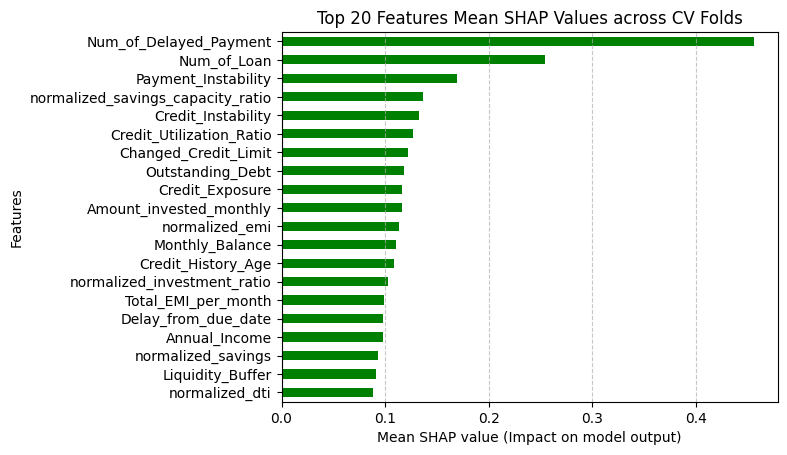

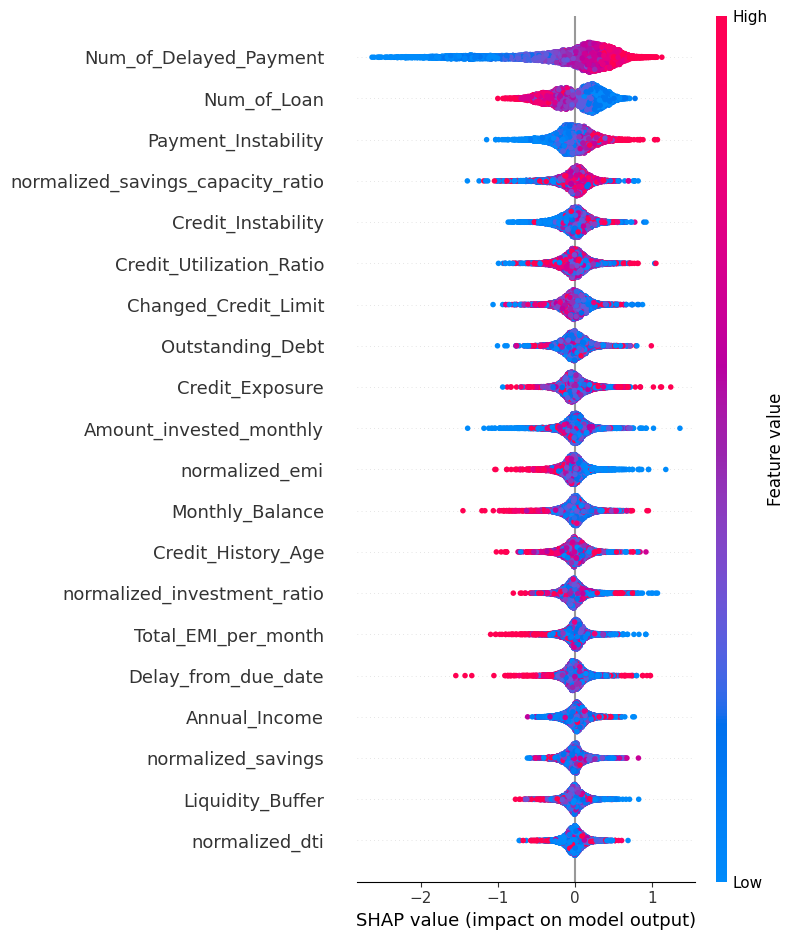

In [45]:
folds = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
shap_values_list = []

for train_idx, val_idx in folds.split(X,y):

    xgb_m = XGBClassifier(enable_categorical=True, tree_method="hist").fit(X.iloc[train_idx], y.iloc[train_idx])

    explainer = shap.TreeExplainer(xgb_m)
    shap_fold = explainer.shap_values(X.iloc[val_idx])
    shap_values_list.append(shap_fold)

all_shap = np.vstack(shap_values_list)
mean_shap = np.abs(all_shap).mean(axis=0)

feature_importance = pd.Series(mean_shap, index=X.columns).sort_values(ascending=False)

#print("Top Features - Mean Absolute SHAP values:")
#print(feature_importance)

plt.Figure(figsize=(10, 6))
feature_importance.head(20).plot(kind="barh", color="green").invert_yaxis()
plt.title("Top 20 Features Mean SHAP Values across CV Folds")
plt.xlabel("Mean SHAP value (Impact on model output)")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

shap.summary_plot(all_shap, X.iloc[np.concatenate([v for _, v in folds.split(X,y)])])

In [46]:
scale_pos_weight = len(y[y==0]) / len([y==1])

folds = KFold(n_splits=7, shuffle=True, random_state=42)

auc_scores = []
ks_scores = []

for train_idx, val_idx in folds.split(X):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    random_state=42)
    
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:,1]

    # AUC
    auc = roc_auc_score(y_val, y_prob)
    auc_scores.append(auc)

    # KS Statistic
    ks = ks_2samp(
        y_prob[y_val==0],
        y_prob[y_val==1]
    ).statistic
    ks_scores.append(ks)


print("AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

print("KS per fold:", ks_scores)
print("Mean KS:", np.mean(ks_scores))

AUC per fold: [0.642922165888521, 0.6028401535343682, 0.6701403508771929, 0.6420745980928776, 0.6341705786075289, 0.5932305475674494, 0.6178400972341624]
Mean AUC: 0.6290312131145858
KS per fold: [np.float64(0.23187609740141515), np.float64(0.1767706681996876), np.float64(0.2668649885583524), np.float64(0.21548360815633355), np.float64(0.21765079707668603), np.float64(0.1575326692215484), np.float64(0.19035958853348353)]
Mean KS: 0.20807691673535808


In [47]:
scale_pos_weight = len(y[y==0]) / len([y==1])

folds = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

auc_scores = []
ks_scores = []

for train_idx, val_idx in folds.split(X, y):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    random_state=42)
    
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:,1]

    # AUC
    auc = roc_auc_score(y_val, y_prob)
    auc_scores.append(auc)

    # KS Statistic
    ks = ks_2samp(
        y_prob[y_val==0],
        y_prob[y_val==1]
    ).statistic
    ks_scores.append(ks)


print("AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

print("KS per fold:", ks_scores)
print("Mean KS:", np.mean(ks_scores))

AUC per fold: [0.604480466340908, 0.631603588499679, 0.6093493614896197, 0.6325236022924544, 0.6424802620627333, 0.6456362988689999, 0.6442900822275655]
Mean AUC: 0.630051951683137
KS per fold: [np.float64(0.1580067840030362), np.float64(0.20422522651066563), np.float64(0.18262050843023947), np.float64(0.2108184109771468), np.float64(0.22491736225060047), np.float64(0.22949802594472646), np.float64(0.23086650636744144)]
Mean KS: 0.2058504034976938


In [48]:
select_features = feature_importance.head(20).index

X_ = X[select_features]

In [49]:
folds = KFold(n_splits=7, shuffle=True, random_state=42)

auc_scores = []
ks_scores = []

for train_idx, val_idx in folds.split(X_):

    X_train, X_val = X_.iloc[train_idx], X_.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    random_state=42)
    
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:,1]

    # AUC
    auc = roc_auc_score(y_val, y_prob)
    auc_scores.append(auc)

    # KS Statistic
    ks = ks_2samp(
        y_prob[y_val==0],
        y_prob[y_val==1]
    ).statistic
    ks_scores.append(ks)


print("AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

print("KS per fold:", ks_scores)
print("Mean KS:", np.mean(ks_scores))

AUC per fold: [0.641103063929322, 0.610705596107056, 0.6657650648360032, 0.6487658783434886, 0.633317745523001, 0.5943347761132336, 0.6226558562831649]
Mean AUC: 0.6309497115907527
KS per fold: [np.float64(0.24303140458123626), np.float64(0.18577426266919847), np.float64(0.2515209763539283), np.float64(0.23026036467118777), np.float64(0.23601143905465927), np.float64(0.15628081653862733), np.float64(0.18839118963626122)]
Mean KS: 0.21303863621501407


In [50]:
folds = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

auc_scores = []
ks_scores = []

for train_idx, val_idx in folds.split(X_, y):

    X_train, X_val = X_.iloc[train_idx], X_.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    random_state=42)
    
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:,1]

    # AUC
    auc = roc_auc_score(y_val, y_prob)
    auc_scores.append(auc)

    # KS Statistic
    ks = ks_2samp(
        y_prob[y_val==0],
        y_prob[y_val==1]
    ).statistic
    ks_scores.append(ks)


print("AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

print("KS per fold:", ks_scores)
print("Mean KS:", np.mean(ks_scores))

AUC per fold: [0.6057435718013188, 0.6320866328981474, 0.6066339088249982, 0.6326870942427053, 0.6412406958217403, 0.6444355389319322, 0.6493320865615816]
Mean AUC: 0.630308504154632
KS per fold: [np.float64(0.19474358366146402), np.float64(0.20622577346555374), np.float64(0.16540331977836437), np.float64(0.21771479869682053), np.float64(0.23159080640175025), np.float64(0.22547867129753318), np.float64(0.24797993291180573)]
Mean KS: 0.21273384088761313
